# Sampling Distributions and the Central Limit Theorem

**Definition.** For a fixed population and fixed sample size $k\in \mathbb{N}$, a collection of values of the mean over $n$ samples of size $k$ forms what we call a <span style="color:green; font-weight:bold">sampling distribution</span>.

Suppose that we have a sampling distribution:

$$X =\left\{X_1, X_2, \cdots, X_n\right\}$$

where $\bar x_i$ is the mean of the sample $X_i$.

For a sampling distribution, we know that:
- The sample size is $k$ for all $X_i$.
- The number of samples in our sampling distribution is $n$.

We refer to the <span style="color:blue; font-weight:bold">grand mean</span> $\bar x$ as the mean of the $n$ sample means, e.g.

$$\bar x = \sum_{i=1}^n\frac{\bar x_i}{n}$$

## Two Vital Theorems

The <span style="color:blue; font-weight:bold">Centrol Limit Theorem</span> (CLT) and <span style="color:blue; font-weight:bold">Law of Large Numbers</span> govern how sampling distributions work:

1. **Central Limit Theorem.** The means $\bar x_i$ of a sampling distribution are approximately normal (bell-shaped) and centered upon $\mu_0$, the population average. Additionally, as sample size $k$ increases, $\bar x \rightarrow \mu_0$.
2. **Law of Large Numbers.** As the number of samples $n$ in our sampling distribution increases, our estimates of the population mean $\mu_0$ increase in accuracy.

Thus, the CLT guarantees a bell-shaped distribution centered upon the population average, and the Law of Large Numbers works like a lever that allows us to control the accuracy. Increased sample size $k$ leads to increased accuracy by the CLT, and increased number of samples $n$ leads to increased accuracy by the Law of Large Numbers.

The Law of Large Numbers is vital due to the fact that the sample size is often limited. For example, sample size should be kept to less than $10\%$ of the population size. The population of all SAT scores for Forsyth County, GA, in 2025 may contain a few thousand items, while the population of SAT scores for the United States will contain millions of items. When the size of the population the sampling distribution is drawn from is limited, the Law of Large Numbers allows us to take many more samples to improve accuracy.

## Law of Large Numbers

If $\bar x$ is the grand mean of $n$ many sample averages $\bar x_i$ which are all have the same sample size $k$ and are drawn from the same population (or distribution) with mean $\mu$, then

$$n \rightarrow \infty \implies \bar{x} \rightarrow \mu$$

## Central Limit Theorem

Assume $\bar x$ is the grand mean of $n$ many sample averages $\bar x_i$ which all have the sample size $k$ and are drawn from the same population (or distribution) with mean $\mu$ and population standard deviation $\sigma$. For large values of $k$, this sampling distribution can be assumed approximately normal. Specifically, the sampling distribution can be assumed to be

$$N\left(\mu, \frac{\sigma}{\sqrt{k}} \right)$$

## Getting Started

To prepare for the examples and demonstrations, we two things. First, we need data to work with. Second, we need our main sampling function: **sample.data.frame**.

**Run the cell below to load 4 data sets.**

In [1]:
united <- read.csv('http://faculty.ung.edu/rsinn/data/united.csv')
pers <- read.csv('http://faculty.ung.edu/rsinn/data/personality.csv')
airports <- read.csv('http://faculty.ung.edu/rsinn/data/airports.csv')
births <-  read.csv('http://faculty.ung.edu/rsinn/data/baby.csv')

We will use three functions to perform the sampling:

1. **rflip** -- simulates a coin flip or binomial distribution.
2. **rspin** -- simulates a spinner which allows for a couple different distributions.
3. **sample.data.frame** -- draw a random sample of rows from a given data frame.

The code for these functions has been adapted from the documentation of the classic *mosaic* package which is still available in R given that you have the correct versioning for R and all mosaic's required dependencies.

**Run the cell below to activate the rflip() function:**

<font color="green"><center><b>rflip</b></center></font>

In [22]:
library('mosaic')
rflip(20, prob = .2, summarize = TRUE)[1,2]

[1] 3

## Example 1: M&M's

A collection vat in the manufacturing process at the M&M plant has millions of unsorted candies. There is 25\% chance of drawing a red candy. What is the expected number of red candies that will be drawn if we draw a sample of size 50?

The main <span style = 'color:blue;font-weight:bold'>for loop</span> is created below along with a display of middle 90\% of the results distribution indicated by blue vertical lines.

The mean of the simulated distribution is
    12.721

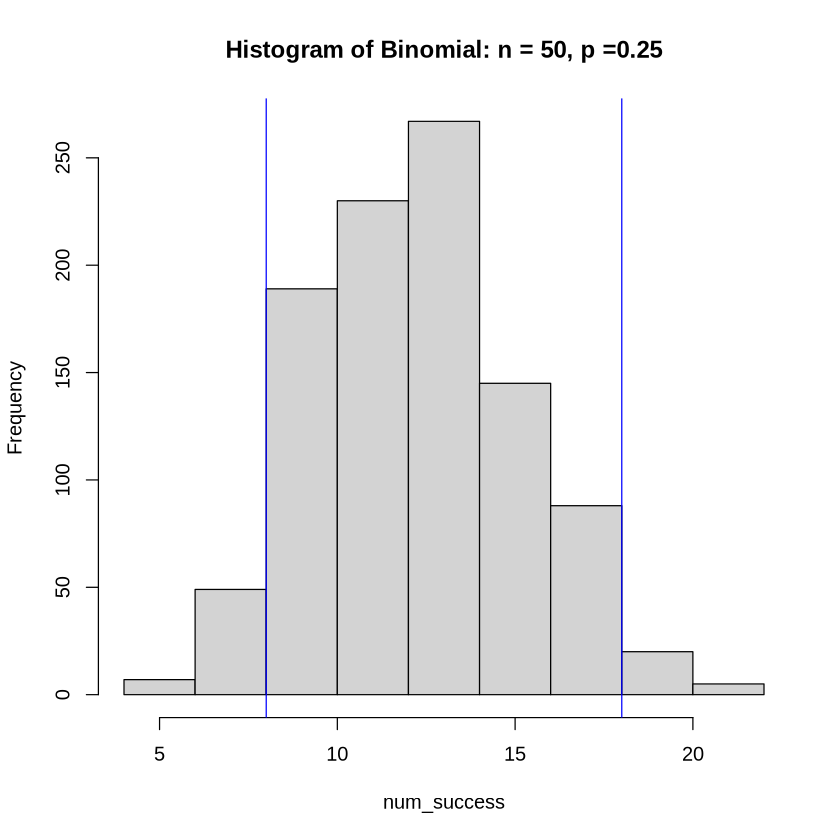

In [24]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- rflip(50, prob = 1/4, summarize = TRUE)[1,2]     # draw 50 candies, count numer of red
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Binomial: n = 50, p =0.25')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile      

The mean of the simulated distribution is
    25.337

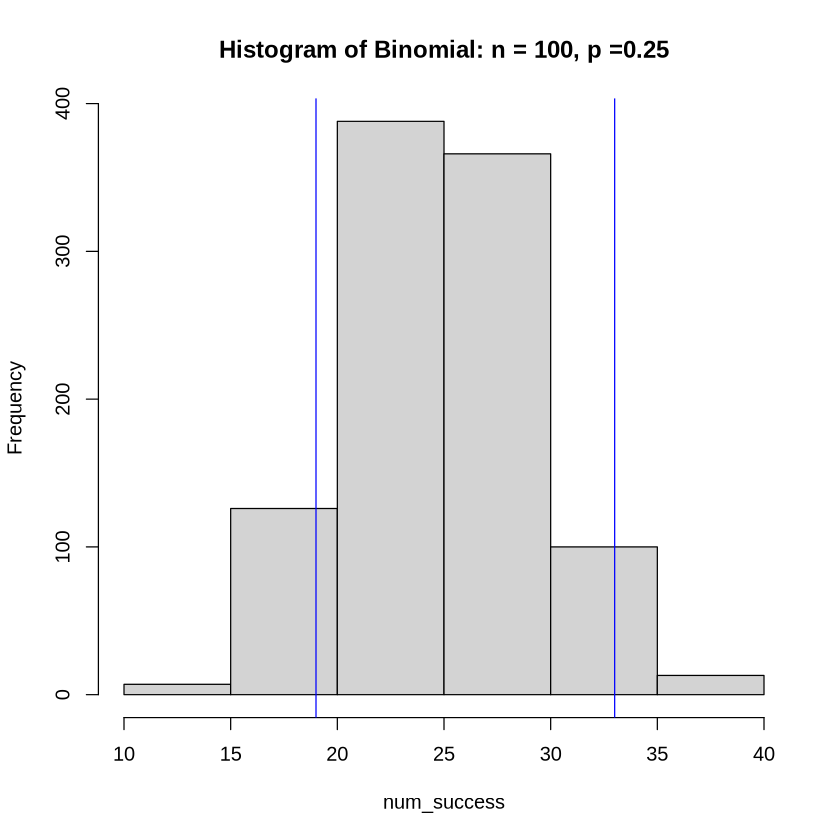

In [25]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- rflip(100, prob = 1/4, summarize = TRUE)[1,2]     # draw 100 candies, count numer of red
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Binomial: n = 100, p =0.25')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile   

The mean of the simulated distribution is
    250.63

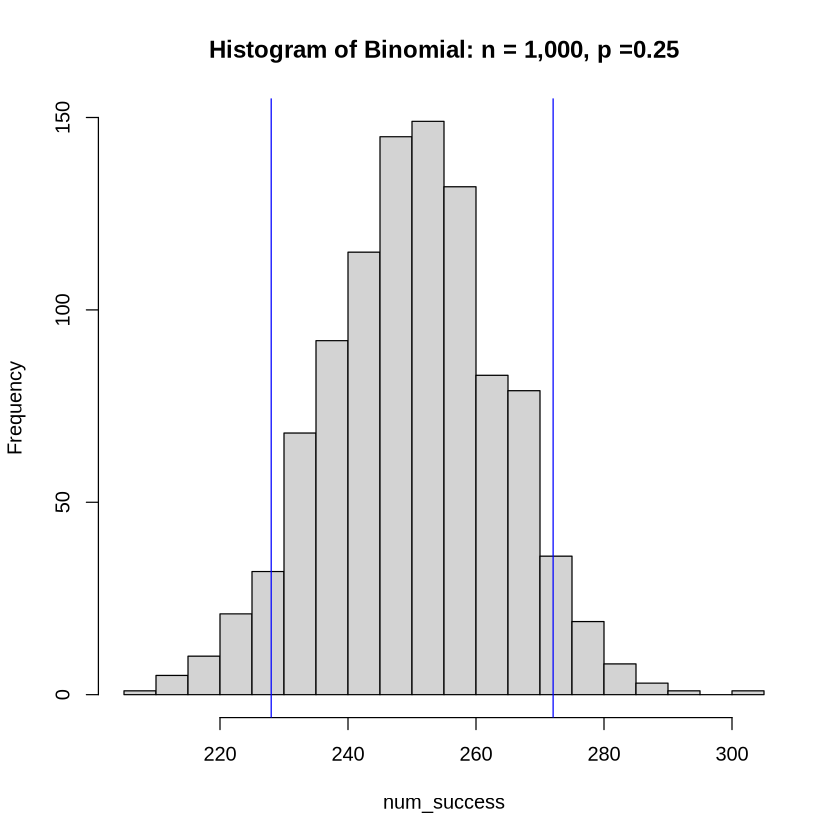

In [35]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- rflip(1000, prob = 1/4, summarize = TRUE)[1,2]     # draw 500 candies, count numer of red
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 15, main = 'Histogram of Binomial: n = 1,000, p =0.25')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

In [37]:
cat('The estimates of the number of red candies drawn at random is as follows:
\n  Sample size: n = 50 , estimate = 12.721 or ', 12.721/50,
'\n  Sample size: n = 100 , estimate = 25.337 or ', 25.337/100,
'\n  Sample size: n = 500 , estimate = 124.494 or ', 124.494/500,
'\n  Sample size: n = 1000 , estimate = 25.63 or ', 250.63/1000)

The estimates of the number of red candies drawn at random is as follows:

  Sample size: n = 50 , estimate = 12.721 or  0.25442 
  Sample size: n = 100 , estimate = 25.337 or  0.25337 
  Sample size: n = 500 , estimate = 124.494 or  0.248988 
  Sample size: n = 1000 , estimate = 25.63 or  0.25063

## The sample.data.frame Function

In [38]:
sample.data.frame <- function(x, size, replace = FALSE, prob = NULL, groups=NULL, 
                              orig.ids = TRUE, fixed = names(x), shuffled = c(),
                              invisibly.return = NULL, ...) {
  if( missing(size) ) size = nrow(x)
  if( is.null(invisibly.return) ) invisibly.return = size>50 
  shuffled <- intersect(shuffled, names(x))
  fixed <- setdiff(intersect(fixed, names(x)), shuffled)
  n <- nrow(x)
  ids <- 1:n
  groups <- eval( substitute(groups), x )
  newids <- sample(n, size, replace=replace, prob=prob, ...)
  origids <- ids[newids]
  result <- x[newids, , drop=FALSE]
  
  idsString <- as.character(origids)
  
  for (column in shuffled) {
    cids <- sample(newids, groups=groups[newids])
    result[,column] <- x[cids,column]
    idsString <- paste(idsString, ".", cids, sep="")
  }
  
  result <-  result[ , union(fixed,shuffled), drop=FALSE]
  if (orig.ids) result$orig.id <- idsString
    
  if (invisibly.return) { return(invisible(result)) } else {return(result)}
}

## Example 2: Narcissism

The mean of the simulated distribution is
    4.6642

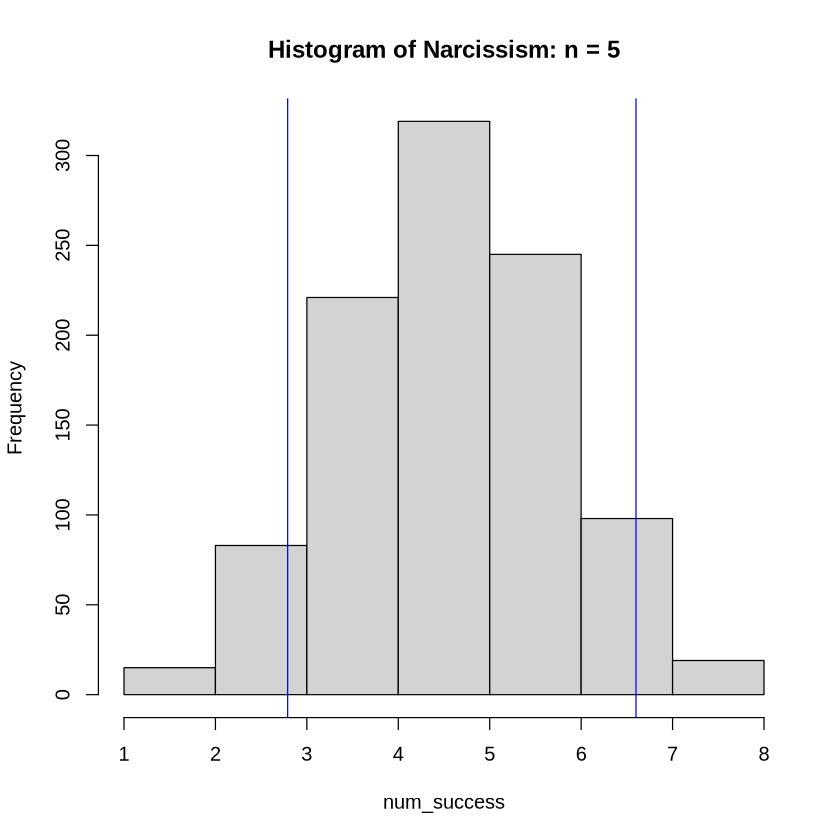

In [46]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- mean(sample.data.frame(pers, 5, orig.ids = F)[ , 'Narc'])     # draw samples of size 5
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Narcissism: n = 5')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

The mean of the simulated distribution is
    4.6884

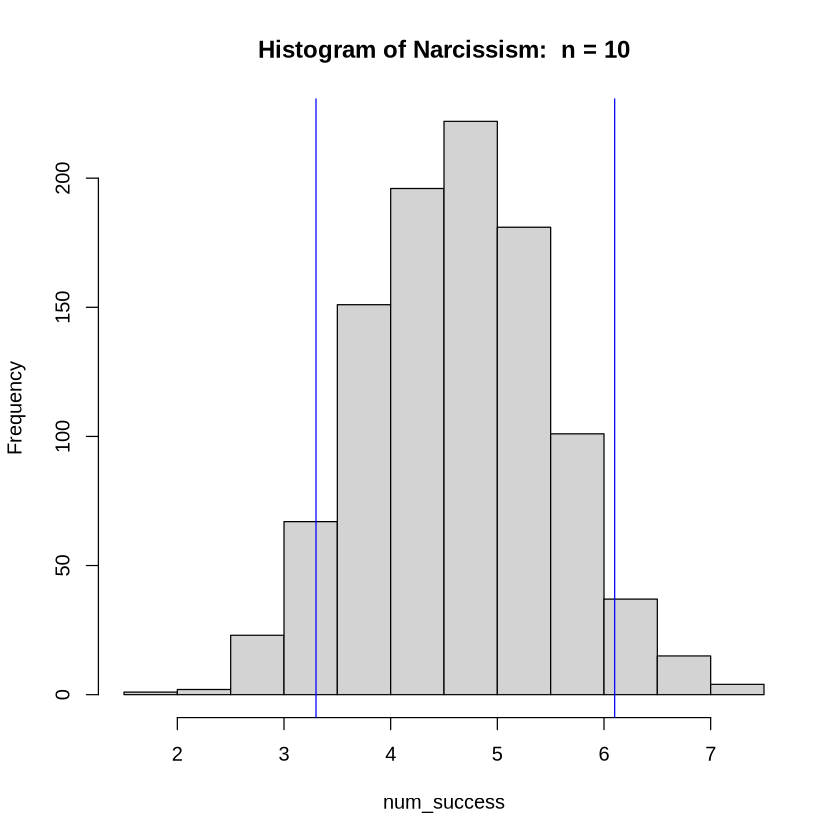

In [50]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- mean(sample.data.frame(pers, 10, orig.ids = F)[ , 'Narc'])     # draw samples of size 10
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Narcissism:  n = 10')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

The mean of the simulated distribution is
    4.683667

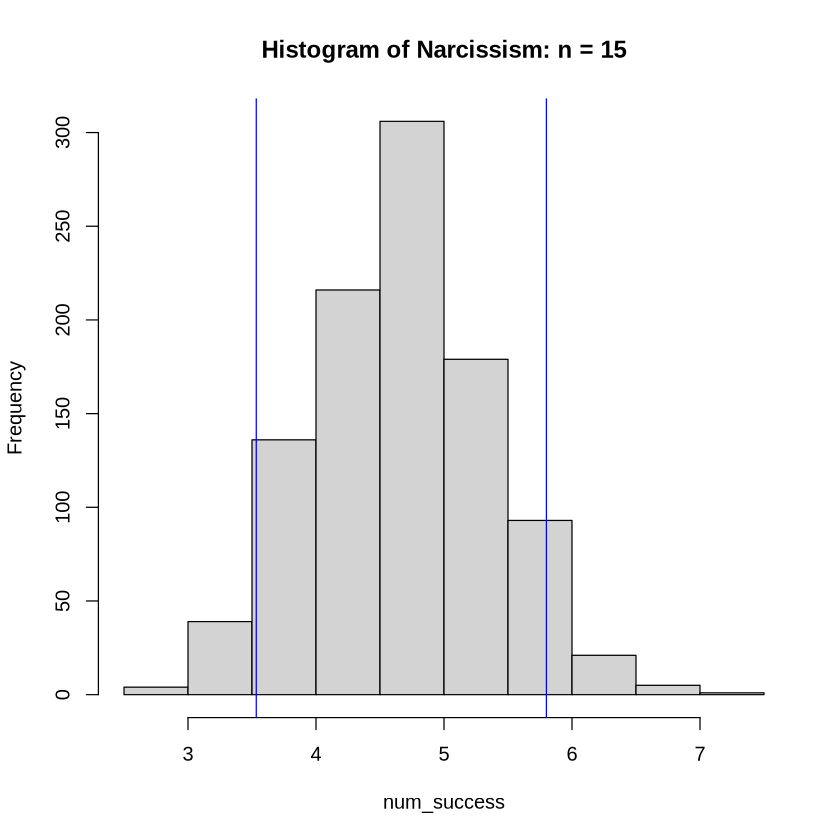

In [51]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- mean(sample.data.frame(pers, 15, orig.ids = F)[ , 'Narc'])     # draw samples of size 15
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Narcissism: n = 15')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

The mean of the simulated distribution is
    4.680333

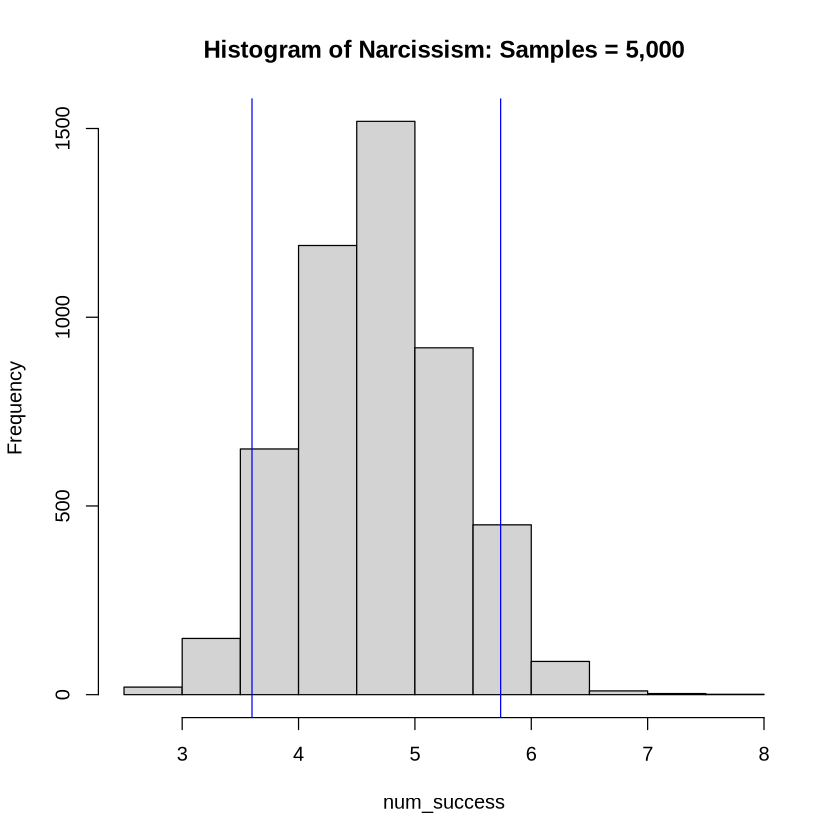

In [52]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 5000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- mean(sample.data.frame(pers, 15, orig.ids = F)[ , 'Narc'])     # draw samples of size 15
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Narcissism: Samples = 5,000')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

In [24]:
mean(pers$Narc)

[1] 4.689922

In [53]:
cat('The estimates of the number of red candies drawn at random is as follows:
\n  Sample size: n = 5 , estimate = 4.6642
\n  Sample size: n = 10 , estimate = 4.6884
\n  Sample size: n = 15 , estimate = 4.683667')

The estimates of the number of red candies drawn at random is as follows:

  Sample size: n = 5 , estimate = 4.6642

  Sample size: n = 10 , estimate = 4.6884

  Sample size: n = 15 , estimate = 4.683667

## Example 3: United Flight Delays

In [28]:
mean(united$Delay)

[1] 16.65816

The mean of the simulated distribution is
    16.4524

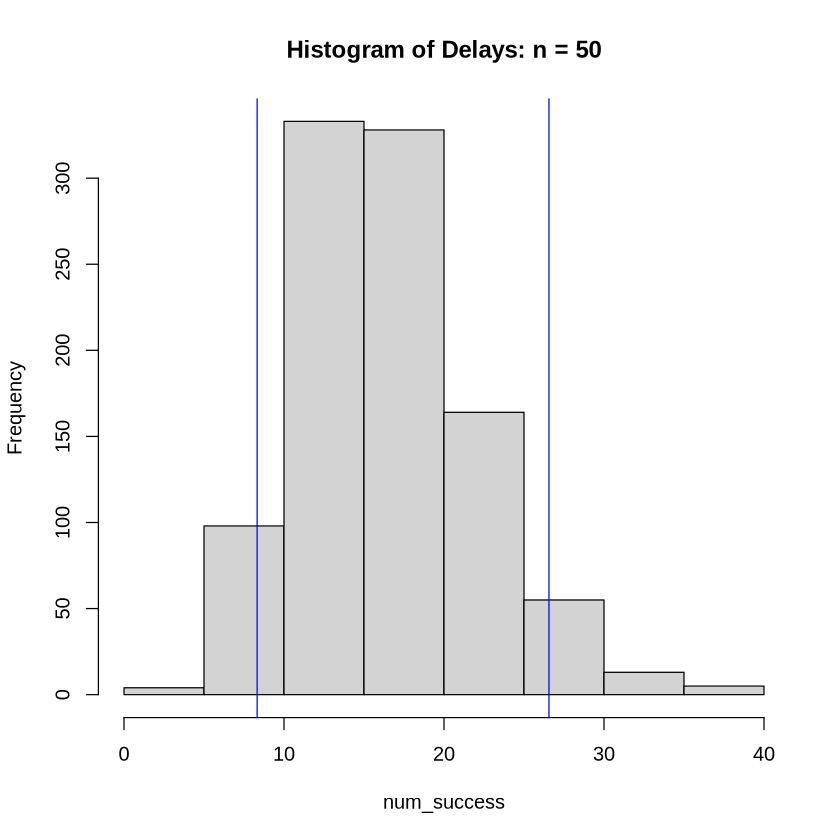

In [55]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- mean(sample.data.frame(united, 50, orig.ids = F)[ , 'Delay'])     # draw samples of size 50
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Delays: n = 50')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

The mean of the simulated distribution is
    16.72987

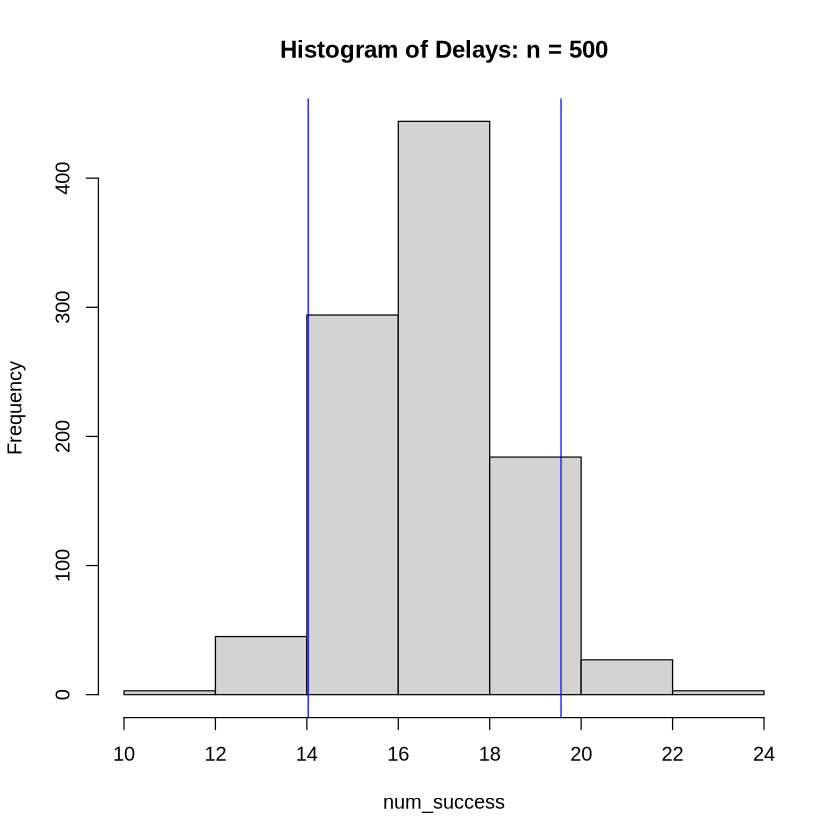

In [56]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- mean(sample.data.frame(united, 500, orig.ids = F)[ , 'Delay'])     # draw samples of size 500
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Delays: n = 500')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

The mean of the simulated distribution is
    16.67711

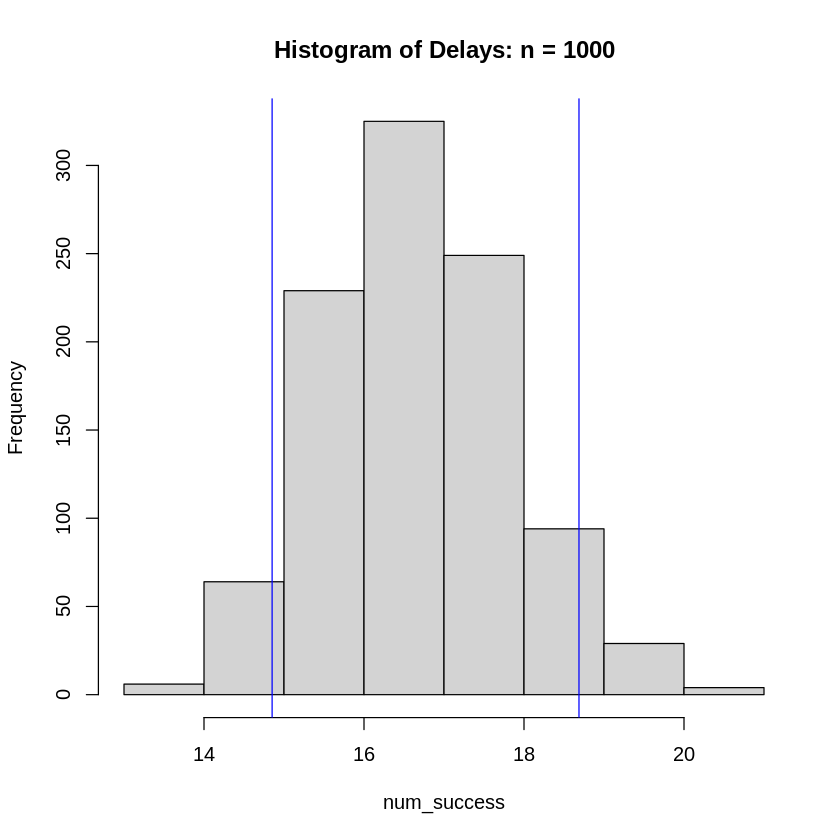

In [31]:
num_success <- c()     # create a vector to store the number of successes for each sample drawn
num_samps = 1000       # set the number of samples to be drawn

for (i in 1:num_samps){
    temp <- mean(sample.data.frame(united, 1000, orig.ids = F)[ , 'Delay'])     # draw samples of size 500
    num_success[i] <- temp     # count and store the number of red candies from this trial
}

lower <- quantile(num_success, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_success, prob = 0.95)     # Calcuate the 95th percentile.
cat('The mean of the simulated distribution is\n   ',mean(num_success) )
hist(num_success, breaks = 8, main = 'Histogram of Delays: n = 1000')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile

In [32]:
mean(united$Delay)

[1] 16.65816